# Time Analysis



## Loading libraries

In [1]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocess
from scipy import stats

# Configuración matplotlib
plt.style.use('ggplot') 

# Paths
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from paths import Paths

# Scripts
from visualization_scripts import qq_grapher, boxplots_grapher, corrmap_calc, barplot_grapher
from eda_scripts import unique_values
from stat_analysis_scripts import descriptive_statistics, summary_statistics, interpret_statistics, anova_test, posthoc_test

## Data Loading

In [2]:
## Dowload DataSet:

data = pd.read_csv(str(Paths.DATA_PROCESSED)+"/preprocess_data.csv")
print(data.head(5))

         date  precipitation  temp_max  temp_min  wind  weather  year  month  \
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012      1   
1  2012-01-02           10.9      10.6       2.8   4.5     rain  2012      1   
2  2012-01-03            0.8      11.7       7.2   2.3     rain  2012      1   
3  2012-01-04           20.3      12.2       5.6   4.7     rain  2012      1   
4  2012-01-05            1.3       8.9       2.8   6.1     rain  2012      1   

   day  
0    1  
1    2  
2    3  
3    4  
4    5  


## Creating Grouped Tables for Temporal Analysis of Variables
Sometimes, depending on the type of analysis and other factors, it is necessary to group data to continue with the analysis. This happens a lot with the analysis of time series or locations such as cities or points of sale.

In this case, to see the behavior of the variables over the months and years, we make the following grouped tables.

In [3]:
# Goup by year-month
datapmonthyear = data.groupby(["month", "year"]).agg({
    "precipitation": "mean",
    "temp_max": "mean",
    "temp_min": "mean",
    "wind": "mean"
}).reset_index()

# Goup by year
datapyear = datapmonthyear.groupby(["year"]).agg({
    "precipitation": "sum",
    "temp_max": "mean",
    "temp_min": "mean",
    "wind": "mean"
}).reset_index()

# Goup by month
datapmont = data.groupby(["month"]).agg({
    "precipitation": "sum",
    "temp_max": "mean",
    "temp_min": "mean",
    "wind": "mean"
}).reset_index()

print(datapmonthyear.head(5))
print()
print(datapyear)
print()
print(datapmont)

   month  year  precipitation   temp_max  temp_min      wind
0      1  2012       5.590323   7.054839  1.541935  3.829032
1      1  2013       3.409677   6.106452  0.796774  2.835484
2      1  2014       3.032258   9.600000  4.096774  3.122581
3      1  2015       3.000000  10.154839  4.351613  2.429032
4      2  2012       3.182759   9.275862  3.203448  3.744828

   year  precipitation   temp_max  temp_min      wind
0  2012      40.135017  15.262433  7.277823  3.357580
1  2013      27.317565  16.023692  8.140363  2.986623
2  2014      40.631782  16.933719  8.618111  3.357972
3  2015      37.525330  17.393271  8.811050  3.137363

    month  precipitation   temp_max   temp_min      wind
0       1          466.0   8.229032   2.696774  3.054032
1       2          422.0   9.860177   4.054867  3.692920
2       3          606.2  12.387097   4.858871  3.558871
3       4          375.4  15.020000   6.362500  3.500833
4       5          207.5  19.295968   9.614516  3.120161
5       6          1

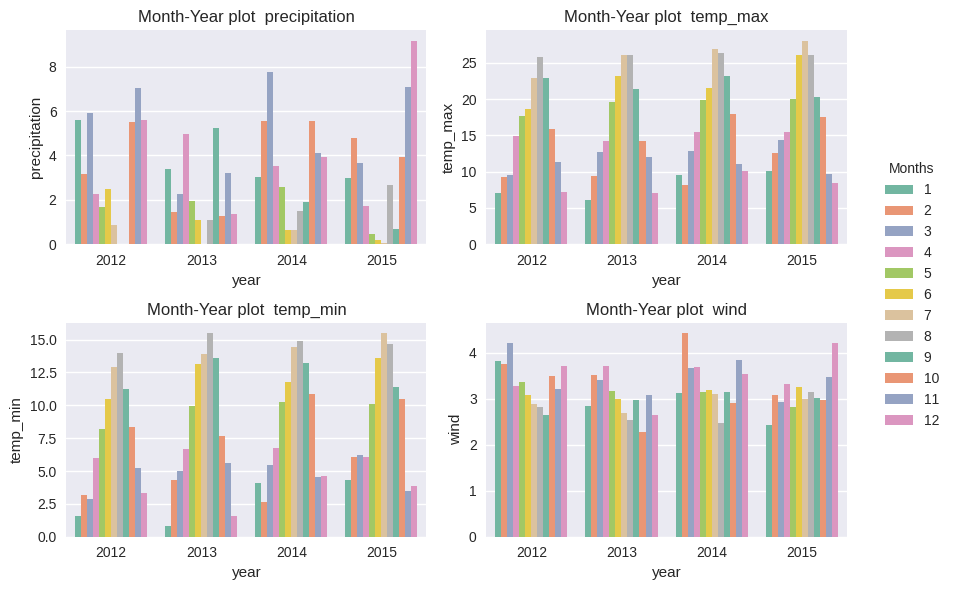

In [4]:
numerical_columns = ['precipitation', 'temp_max', 'temp_min', 'wind']

barplot_grapher(datapmonthyear, numerical_columns, x_var="year", hue="month", 
                title_prefix="Month-Year plot ", legend_title = "Months")


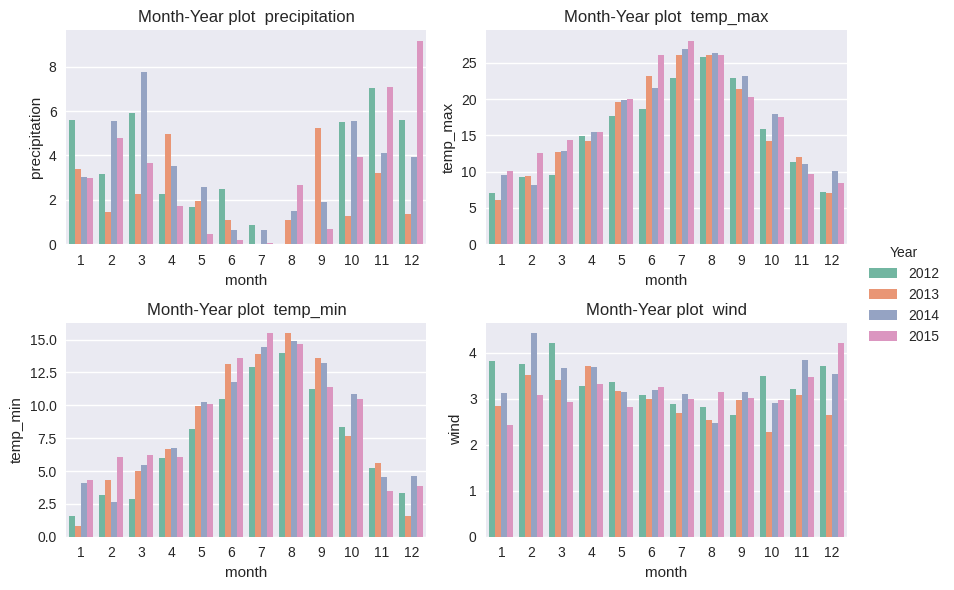

In [5]:
barplot_grapher(datapmonthyear, numerical_columns, x_var="month", hue="year", 
                title_prefix="Month-Year plot ", legend_title = "Year")

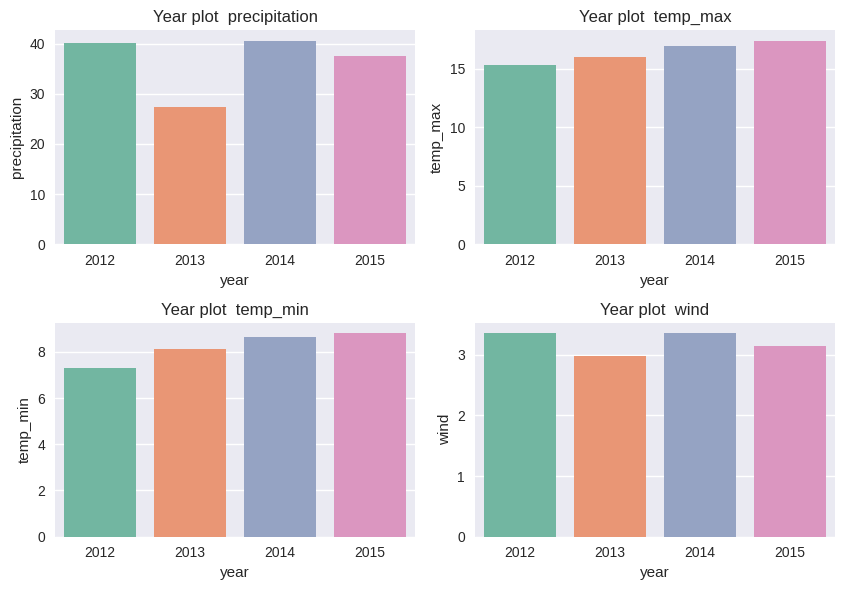

In [6]:
barplot_grapher(datapyear, numerical_columns, x_var="year", hue=None, 
                title_prefix="Year plot ")

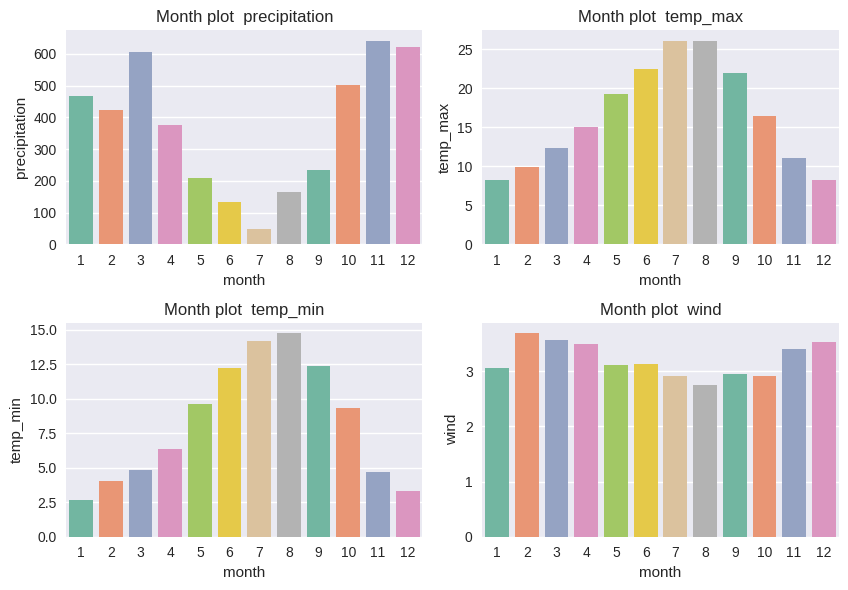

In [7]:
barplot_grapher(datapmont, numerical_columns, x_var="month", hue=None, 
                title_prefix="Month plot ")

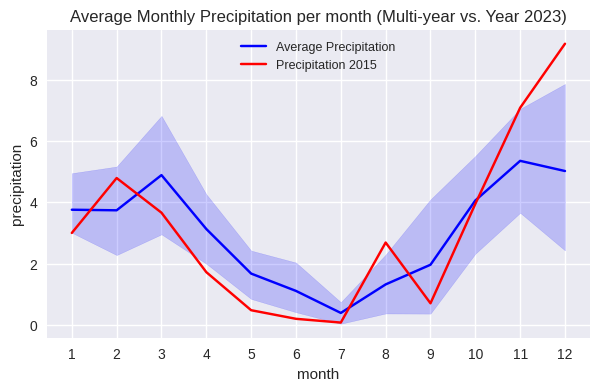

In [8]:
fig, ax = plt.subplots(figsize = (7,4))

sns.lineplot(data = datapmonthyear, x = "month", 
             y = "precipitation", color = "blue", ax = ax, label = "Average Precipitation")

dfr = datapmonthyear[datapmonthyear["year"] == 2015]

sns.lineplot(data = datapmonthyear[datapmonthyear["year"] == 2015], 
             x = "month", y = "precipitation", color="red", ax = ax, label = "Precipitation 2015")

ax.set_xticks(range(1, 13))
ax.set_title("Average Monthly Precipitation per month (Multi-year vs. Year 2023)")
ax.legend(loc="upper center",fontsize=9, ncol=1)
plt.show()